# Sentiment Model Comparison: DistilBERT vs RoBERTa vs Twitter-RoBERTa

## Purpose

This notebook provides a **systematic comparative analysis of transformer-based sentiment classification models**, focusing on both:

- **Model architecture differences (general vs domain-specific)**
- **Data scaling behavior across multiple dataset sizes**

The models evaluated include:
- DistilBERT (lightweight general-purpose transformer)
- RoBERTa-base (larger general-purpose transformer)
- Twitter-RoBERTa (domain-specific transformer trained on Twitter data)

The primary objective is to understand how **model capacity and domain alignment jointly influence performance, efficiency, and scalability** in sentiment analysis tasks.

---

## What This Notebook Does

- Loads pre-computed experimental results from all models:
  - DistilBERT experiments
  - RoBERTa-base experiments
  - Twitter-RoBERTa experiments

- Performs comparative analysis across:
  - Small dataset (~100k samples)
  - Medium dataset (~200k samples)
  - Large dataset (~400k samples)

- Evaluates and compares models using:
  - Accuracy  
  - F1-score  
  - ROC-AUC  
  - Training time  

- Generates research-grade visualizations:
  - Performance vs dataset size
  - Model efficiency trade-offs
  - Scaling behavior curves
  - Performance gap analysis

---

## Key Research Focus

This notebook is designed to answer the following core questions:

- How does **model size affect sentiment classification performance**?
- Does **domain-specific pretraining (Twitter-RoBERTa)** provide consistent advantages over general models?
- How do models behave under **dataset scaling conditions**?
- What is the trade-off between:
  - Performance improvement  
  - Computational cost  
  - Data efficiency  

---

## Role in Overall Project

This notebook represents the **final integration stage of Phase 1 (comparative study)** and serves as a bridge toward Phase 2 (cross-domain analysis).

It consolidates results from previous experiments and is used to:

- Compare **DistilBERT vs RoBERTa vs Twitter-RoBERTa**
- Analyze **scaling behavior across architectures**
- Evaluate **data efficiency vs model complexity**
- Identify optimal trade-offs for real-world sentiment systems

---

## Key Research Contributions

This analysis aims to provide insights into:

> How transformer model performance is jointly influenced by architectural capacity, domain-specific pretraining, and dataset scale in sentiment classification tasks.

Specifically, it highlights:

- The role of **domain alignment in improving data efficiency**
- The impact of **model size on performance ceilings**
- The presence of **diminishing returns in dataset scaling**
- The trade-off between **accuracy and computational cost**

---

## Connection to Overall Study

This notebook directly connects to:

- Baseline ML models (Logistic Regression + TF-IDF)
- DistilBERT experiments (general transformer baseline)
- Twitter-RoBERTa experiments (domain-specific model study)

It forms the **central comparative layer** of the entire sentiment analysis research pipeline and supports the transition toward:

> Cross-domain sentiment analysis and brand-level sentiment modeling (Phase 2)

In [ ]:
!uv pip install transformers datasets tqdm accelerate

In [ ]:
# !pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -U transformers accelerate

Checking GPU

In [1]:
import torch
torch.cuda.is_available()

True

In [ ]:
# !nvidia-smi

In [ ]:
# ! pip install transformers[torch] datasets tqdm accelerate --only-binary :all: -i https://pypi.tuna.tsinghua.edu.cn/simple

# Dependencies

In [2]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, pipeline, BertTokenizerFast
from transformers import (
    DistilBertForSequenceClassification, 
    DistilBertTokenizerFast,
    AutoTokenizer,
    AutoModelForSequenceClassification
)
import time
import os
import json, pickle as pkl



# Loading Dataset

In [ ]:
# ! pip install kaggle

get kaggle.json from the kaggle and add to working environment

In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

Importing twitter sentiment dataset

In [ ]:
# !kaggle datasets download -d kazanova/sentiment140

if data set is downloaded using: !kaggle datasets download -d kazanova/sentiment140

In [ ]:
# # extracting the compressed dataset

# from zipfile import ZipFile
# dataset = '/content/sentiment140.zip'

# with ZipFile(dataset, 'r') as zip:
#   zip.extractall()
#   print('The dataset is extracted successfully')

Use datasets/kazanova/sentiment140 from kaggle

In [3]:
# colab
# df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1', header = None)

#colab + dataset saved on drive
# df = pd.read_csv('/content/drive/MyDrive/Sentiment Analysis Project/datasets/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1', header = None)

#kaggle
df = pd.read_csv(
    '/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv',
    encoding='ISO-8859-1',
    header=None
)

df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Converting labels
df['target'] = df['target'].replace(4,1)

# Keeping only needed columns
df = df[['text', 'target']]


## Create 3 datasets

- Dataset 1: Small (50k per class → 100k total)
- Dataset 2: Medium (100k per class → 200k total) MAIN
- Dataset 3: Large (200k per class → 400k total)

In [4]:
df_small = df.groupby('target').sample(50000, random_state=42).reset_index(drop=True)

In [5]:
df_medium = df.groupby('target').sample(100000, random_state=42).reset_index(drop=True)

In [6]:
df_large = df.groupby('target').sample(200000, random_state=42).reset_index(drop=True)

Sanity check

In [7]:
print("Small:\n", df_small['target'].value_counts())
print("\nMedium:\n", df_medium['target'].value_counts())
print("\nLarge:\n", df_large['target'].value_counts())

Small:
 target
0    50000
1    50000
Name: count, dtype: int64

Medium:
 target
0    100000
1    100000
Name: count, dtype: int64

Large:
 target
0    200000
1    200000
Name: count, dtype: int64


In [ ]:
# Uncomment below code to save the datasets

# df_small.to_csv("sentiment_small.csv", index=False)
# df_medium.to_csv("sentiment_medium.csv", index=False)
# df_large.to_csv("sentiment_large.csv", index=False)

# df_small.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_small.csv", index=False)
# df_medium.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_medium.csv", index=False)
# df_large.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_large.csv", index=False)

# REUSABLE Twitter-RoBERTa EXPERIMENT PIPELINE

## Metrics function

In [8]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)

  precision, recall,f1, _ = precision_recall_fscore_support(labels, preds, average = 'binary')
  acc = accuracy_score(labels, preds)

  probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
  roc = roc_auc_score(labels, probs)

  return {
      "accuracy": acc,
      "f1": f1,
      "roc_auc": roc,
      "precision": precision,
      "recall": recall
  }




MAIN reusable function

kaggle

Code suitable to plot:
- loss curves
- error analysis (predictions saved)
- proper logging for research plots
- reproducible experiment setup

In [9]:
def run_experiment(
    df,
    dataset_name="dataset",
    save_dir="/kaggle/working/models",
    model_name="cardiffnlp/twitter-roberta-base-sentiment"
):

    print(f"Running experiment on {dataset_name} using {model_name}")

    # Save directory
    exp_path = os.path.join(save_dir, dataset_name)
    os.makedirs(exp_path, exist_ok=True)

    # Train / Validation Split
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        df['text'].tolist(),
        df['target'].tolist(),
        test_size=0.2,
        random_state=42,
        stratify=df['target']
    )

    with open(os.path.join(exp_path, "data_split_info.json"), "w") as f:
        json.dump({
            "train_size": len(train_texts),
            "val_size": len(val_texts)
        }, f, indent=4)

    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_encodings = tokenizer(
        train_texts,
        truncation=True,
        padding=True,
        max_length=128
    )

    val_encodings = tokenizer(
        val_texts,
        truncation=True,
        padding=True,
        max_length=128
    )

    # Dataset Class
    class SentimentDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels

        def __getitem__(self, idx):
            item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
            item["labels"] = torch.tensor(self.labels[idx])
            return item

        def __len__(self):
            return len(self.labels)

    train_dataset = SentimentDataset(train_encodings, train_labels)
    val_dataset = SentimentDataset(val_encodings, val_labels)

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        ignore_mismatched_sizes=True
    )

    # Training Arguments
    training_args = TrainingArguments(
        output_dir=os.path.join(exp_path, "checkpoints"),

        num_train_epochs=2,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,

        gradient_accumulation_steps=4,
        learning_rate=2e-5,

        eval_strategy="epoch",
        save_strategy="no",

        fp16=True,
        optim="adamw_torch",

        dataloader_num_workers=2,
        dataloader_pin_memory=True,

        logging_strategy="steps",
        logging_steps=100,

        report_to="none"
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    # Training
    start = time.time()
    trainer.train()
    end = time.time()

    trainer.save_state()

    # EVALUATION
    results = trainer.evaluate()

    preds = trainer.predict(val_dataset)

    logits = preds.predictions
    y_true = preds.label_ids
    y_pred = logits.argmax(axis=1)

    # PROBABILITIES (for analysis)
    import numpy as np
    from scipy.special import softmax

    probs = softmax(logits, axis=1)
    confidence = np.max(probs, axis=1)

    # PREDICTION DATASET (ERROR ANALYSIS READY)
    import pandas as pd

    df_preds = pd.DataFrame({
        "text": val_texts,
        "true": y_true,
        "pred": y_pred,
        "confidence": confidence
    })

    df_preds.to_csv(os.path.join(exp_path, "predictions.csv"), index=False)

    # LOSS LOGS (FOR CURVES)
    log_history = trainer.state.log_history

    steps = []
    train_loss = []
    eval_loss = []

    for log in log_history:
        if "loss" in log:
            steps.append(log["step"])
            train_loss.append(log["loss"])

        if "eval_loss" in log:
            eval_loss.append(log["eval_loss"])

    with open(os.path.join(exp_path, "loss_logs.json"), "w") as f:
        json.dump({
            "steps": steps,
            "train_loss": train_loss,
            "eval_loss": eval_loss
        }, f, indent=4)

    # CONFUSION MATRIX
    from sklearn.metrics import confusion_matrix, classification_report

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    with open(os.path.join(exp_path, "confusion_matrix.json"), "w") as f:
        json.dump(cm.tolist(), f, indent=4)

    with open(os.path.join(exp_path, "classification_report.json"), "w") as f:
        json.dump(report, f, indent=4)

    # FINAL RESULTS
    final_results = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": results.get("eval_accuracy"),
        "f1": results.get("eval_f1"),
        "roc_auc": results.get("eval_roc_auc"),
        "training_time_sec": end - start
    }

    # SAVE EVERYTHING
    trainer.save_model(exp_path)
    tokenizer.save_pretrained(exp_path)

    with open(os.path.join(exp_path, "results.json"), "w") as f:
        json.dump(final_results, f, indent=4)

    import pickle as pkl
    with open(os.path.join(exp_path, "results.pkl"), "wb") as f:
        pkl.dump(final_results, f)

    with open(os.path.join(exp_path, "training_args.json"), "w") as f:
        json.dump(training_args.to_dict(), f, indent=4)

    label_map = {0: "negative", 1: "positive"}
    with open(os.path.join(exp_path, "label_map.json"), "w") as f:
        json.dump(label_map, f, indent=4)

    # SUMMARY
    print(f"\nExperiment saved at: {exp_path}")

    print("\n--- Files Generated ---")
    for root, dirs, files in os.walk(exp_path):
        for file in files:
            print(os.path.join(root, file))

    return final_results

# Run all experiments

In [10]:
import transformers
print(transformers.__version__)

5.0.0


In [11]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

CUDA available: True
GPU name: Tesla T4


In [ ]:
# !nvidia-smi

In [12]:
TRAIN_SMALL = True
TRAIN_MEDIUM = True
TRAIN_LARGE = True



In [ ]:

if TRAIN_LARGE:
    results_large = run_experiment(
        df_large,
        dataset_name="df_large-roberta",
        model_name="roberta-base"
    )
    print(results_large)

In [28]:

if TRAIN_MEDIUM:
    results_medium = run_experiment(
        df_medium,
        dataset_name="df_medium-roberta",
        model_name="roberta-base"
    )
    print(results_medium)



In [ ]:
if TRAIN_SMALL:
    results_small = run_experiment(
        df_small,
        dataset_name="df_small-roberta",
        model_name="roberta-base"
    )
    print(results_small)



# Compare results

In [ ]:
results_df = pd.DataFrame([
    results_small,
    results_medium,
    results_large
])

results_df

# Plots

Utilities

In [35]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_results_safe(path):
    import os
    import json

    # if it's a directory → append results.json
    if os.path.isdir(path):
        path = os.path.join(path, "results.json")

    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ File not found: {path}")

    with open(path, "r") as f:
        data = json.load(f)

    return data.get("root", data)

def extract_metric(path, metric="accuracy"):
    data = load_results_safe(path)
    return data.get(metric, 0)

def build_metric_dict(paths):
    return {
        k: load_results_safe(v)
        for k, v in paths.items()
    }

PERFORMANCE vs DATA SIZE

In [36]:
def plot_performance_vs_data(distil_paths, roberta_paths, twitter_paths, metric="accuracy"):
    
    sizes = ["small", "medium", "large"]
    x = np.arange(len(sizes))

    def get_vals(paths):
        vals = []
        for s in sizes:
            data = load_results_safe(paths[s])   # handles dir + file
            vals.append(data.get(metric, 0))
        return vals
    

    distil = get_vals(distil_paths)
    roberta = get_vals(roberta_paths)
    twitter = get_vals(twitter_paths)

    plt.figure(figsize=(10,6))

    plt.plot(x, distil, marker="o", label="DistilBERT")
    plt.plot(x, roberta, marker="o", label="RoBERTa-base")
    plt.plot(x, twitter, marker="o", label="Twitter-RoBERTa")

    plt.xticks(x, sizes)
    plt.xlabel("Dataset Size")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} vs Dataset Size (Scaling Behavior)")
    plt.legend()
    plt.grid()

    plt.show()

TRAINING EFFICIENCY FRONTIER

In [37]:
def plot_efficiency_frontier(distil_paths, roberta_paths, twitter_paths):
    
    sizes = ["small", "medium", "large"]

    def get_vals(paths):
        acc = []
        time = []
        for s in sizes:
            data = load_results_safe(paths[s])
            acc.append(data["accuracy"])
            time.append(data["training_time_sec"])
        return acc, time

    d_acc, d_time = get_vals(distil_paths)
    r_acc, r_time = get_vals(roberta_paths)
    t_acc, t_time = get_vals(twitter_paths)

    plt.figure(figsize=(10,6))

    # --- DistilBERT ---
    plt.plot(d_time, d_acc, marker="o", linestyle="-", label="DistilBERT")

    # --- RoBERTa-base ---
    plt.plot(r_time, r_acc, marker="o", linestyle="-", label="RoBERTa-base")

    # --- Twitter-RoBERTa ---
    plt.plot(t_time, t_acc, marker="o", linestyle="-", label="Twitter-RoBERTa")

    plt.xlabel("Training Time (seconds)")
    plt.ylabel("Accuracy")
    plt.title("Efficiency Frontier: Accuracy vs Training Time")

    plt.legend()
    plt.grid()

    plt.show()

DOMAIN IMPROVEMENT

In [38]:
def plot_domain_gain(roberta_paths, twitter_paths, metric="accuracy"):
    
    sizes = ["small", "medium", "large"]

    gains = []

    for s in sizes:
        r = extract_metric(roberta_paths[s], metric)
        t = extract_metric(twitter_paths[s], metric)
        gains.append(t - r)

    x = np.arange(len(sizes))

    plt.figure(figsize=(10,6))
    plt.bar(x, gains)

    plt.xticks(x, sizes)
    plt.ylabel(f"Δ {metric.upper()}")
    plt.title("Domain Adaptation Gain (Twitter-RoBERTa - RoBERTa-base)")
    plt.grid(axis="y")

    plt.show()

LOSS CURVE COMPARISON

In [86]:
def load_loss(path):
    import json
    import pandas as pd

    with open(path, 'r') as f:
        data = json.load(f)

    # Unwrap "root" if it exists
    if isinstance(data, dict) and "root" in data:
        data = data["root"]

    # 1. Flexible key matching for Training Loss
    # Checks for 'train_loss' first, falls back to 'loss'
    t_loss_values = data.get("train_loss") or data.get("loss")
    steps = data.get("steps")

    if t_loss_values is None or steps is None:
        raise KeyError(f"Missing essential keys in {path}. Found: {list(data.keys())}")

    # 2. Build Train DataFrame
    # Using min() ensures we don't crash if one list is slightly longer
    train_len = min(len(steps), len(t_loss_values))
    train_df = pd.DataFrame({
        "step": steps[:train_len],
        "train_loss": t_loss_values[:train_len]
    })

    # 3. Build Eval DataFrame (Safe handling if missing)
    eval_df = None
    e_loss_values = data.get("eval_loss")
    
    if e_loss_values:
        eval_len = len(e_loss_values)
        # Match eval steps: if 3 evals and 6 steps, it picks steps 200, 400, 600
        step_idx = [int((i + 1) * (len(steps) / eval_len)) - 1 for i in range(eval_len)]
        eval_steps = [steps[i] for i in step_idx]
        
        eval_df = pd.DataFrame({
            "step": eval_steps,
            "eval_loss": e_loss_values
        })

    return train_df, eval_df

In [93]:
# # Debug
# paths = [
#     "/kaggle/input/datasets/aayushparajuli03/distil-small/loss_logs.json",
#     "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_small-twitter/loss_logs.json",
#     "/kaggle/input/notebooks/aayushparajuli03/comparison-distilbert-roberta-twitterroberta/models/df_small-roberta/loss_logs.json"
# ]

# for p in paths:
#     import json
#     with open(p, 'r') as f:
#         d = json.load(f)
    
#     # Check if we need to unwrap "root"
#     if isinstance(d, dict) and "root" in d:
#         content = d["root"]
#     else:
#         content = d
        
#     print(f"Path: ...{p[-40:]}") # Shows the end of the path
#     print(f"Keys found: {list(content.keys())}")
#     print("-" * 30)

In [92]:
def plot_loss_comparison(distil_path, roberta_path, twitter_path):

    import matplotlib.pyplot as plt

    def unpack(path):
        return load_loss(path)

    d_train, d_eval = unpack(distil_path)
    r_train, r_eval = unpack(roberta_path)
    t_train, t_eval = unpack(twitter_path)

    plt.figure(figsize=(10,6))

    # --- TRAIN LOSS ---
    plt.plot(d_train["step"], d_train["train_loss"], label="DistilBERT Train")
    plt.plot(r_train["step"], r_train["train_loss"], label="RoBERTa Train")
    plt.plot(t_train["step"], t_train["train_loss"], label="Twitter-RoBERTa Train")

    # # --- EVAL LOSS ---
    # if d_eval is not None:
    #     plt.plot(d_eval["step"], d_eval["eval_loss"], "--", label="DistilBERT Eval")
    # if r_eval is not None:
    #     plt.plot(r_eval["step"], r_eval["eval_loss"], "--", label="RoBERTa Eval")
    # if t_eval is not None:
    #     plt.plot(t_eval["step"], t_eval["eval_loss"], "--", label="Twitter-RoBERTa Eval")

    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Training Dynamics Comparison (3 Models)")
    plt.legend()
    plt.grid()

    plt.show()

Architectectural improvement

In [40]:
def plot_architecture_gain(distil_paths, roberta_paths, metric="accuracy"):
    
    import numpy as np
    import matplotlib.pyplot as plt

    sizes = ["small", "medium", "large"]

    gains = []

    for s in sizes:
        d = load_results_safe(distil_paths[s])[metric]
        r = load_results_safe(roberta_paths[s])[metric]
        gains.append(r - d)   # RoBERTa - DistilBERT

    x = np.arange(len(sizes))

    plt.figure(figsize=(10,6))
    plt.bar(x, gains)

    plt.xticks(x, sizes)
    plt.ylabel(f"Δ {metric.upper()}")
    plt.title("Architecture Gain (RoBERTa-base - DistilBERT)")
    plt.grid(axis="y")

    #  add values (important)
    for i, v in enumerate(gains):
        plt.text(i, v + 0.001, f"{v:.4f}", ha='center')

    plt.show()

In [69]:
def plot_combined_gains(distil_paths, roberta_paths, twitter_paths, metric="accuracy"):
    
    import numpy as np
    import matplotlib.pyplot as plt

    sizes = ["small", "medium", "large"]

    arch_gain = []
    domain_gain = []

    arch_gain_pct = []
    domain_gain_pct = []

    for s in sizes:
        d = load_results_safe(distil_paths[s])[metric]
        r = load_results_safe(roberta_paths[s])[metric]
        t = load_results_safe(twitter_paths[s])[metric]

        # --- Absolute gains ---
        ag = r - d
        dg = t - r

        arch_gain.append(ag)
        domain_gain.append(dg)

        # --- Percentage gains (safe division) ---
        arch_gain_pct.append(ag / d if d != 0 else 0)
        domain_gain_pct.append(dg / r if r != 0 else 0)

    x = np.arange(len(sizes))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(10,6))

    # --- Absolute bars ---
    bars1 = ax1.bar(x - width/2, arch_gain, width, label="Architecture Gain")
    bars2 = ax1.bar(x + width/2, domain_gain, width, label="Domain Gain")

    ax1.set_xlabel("Dataset Size")
    ax1.set_ylabel(f"Δ {metric.upper()}")
    ax1.set_xticks(x)
    ax1.set_xticklabels(sizes)
    ax1.grid(axis="y")

    # --- Secondary axis for percentage ---
    ax2 = ax1.twinx()
    ax2.plot(x, arch_gain_pct, marker="o", linestyle="--", label="Arch Gain (%)")
    ax2.plot(x, domain_gain_pct, marker="o", linestyle="--", label="Domain Gain (%)")
    ax2.set_ylabel("Relative Gain (%)")

    # --- Labels on bars ---
    for i in range(len(sizes)):
        ax1.text(x[i] - width/2, arch_gain[i] + 0.001, f"{arch_gain[i]:.4f}", ha='center')
        ax1.text(x[i] + width/2, domain_gain[i] + 0.001, f"{domain_gain[i]:.4f}", ha='center')

    # --- Combine legends ---
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left")

    plt.title("Architecture vs Domain Gain (Absolute + Relative)")
    plt.show()

Data path

In [5]:
distil_paths = {
    "small": "/kaggle/input/datasets/aayushparajuli03/distil-small/results.json",
    "medium": "/kaggle/input/notebooks/aayushparajuli03/sentiment-analysis/models/df_medium/results.json",
    "large": "/kaggle/input/notebooks/aayushparajuli03/sentiment-analysis/models/large_200k/results.json"
}

roberta_paths = {
    "small": "/kaggle/input/notebooks/aayushparajuli03/comparison-distilbert-roberta-twitterroberta/models/df_small-roberta/results.json",
    "medium": "/kaggle/input/notebooks/aayushparajuli03/comparison-distilbert-roberta-twitterroberta/models/df_medium-roberta/results.json",
    "large": "/kaggle/input/notebooks/aayushparajuli03/comparison-distilbert-roberta-twitterroberta/models/df_large-roberta/results.json"
}

twitter_paths = {
    "small": "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_small-twitter/results.json",
    "medium": "/kaggle/input/datasets/aayushparajuli03/twitter-medium/results.json",
    "large": "/kaggle/input/datasets/aayushparajuli03/twitter-large/results.json"
}

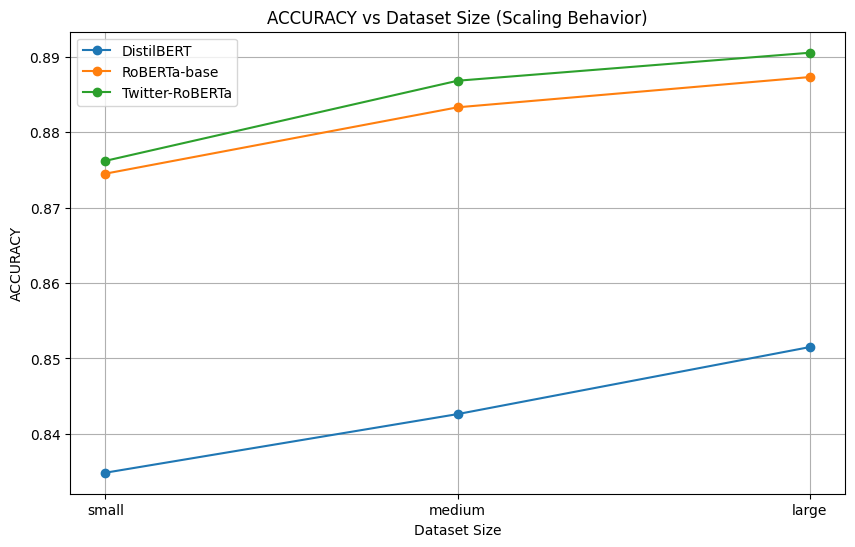

In [25]:
plot_performance_vs_data(distil_paths, roberta_paths, twitter_paths, metric="accuracy")


## 1. Scaling Behavior and Structural Performance Gaps

Model scaling trends reveal **parallel performance trajectories** across dataset sizes.

- **Observed Pattern**:
  All models improve with data, but maintain **consistent relative gaps**.

- **Example Scaling**:
  - DistilBERT: 0.835 → 0.852  
  - Twitter-RoBERTa: 0.876 → 0.891  

- **Key Observation**:
  Performance curves are **parallel, not converging**.

 **Final Insight**:  
> Increasing data volume improves all models uniformly, but **does not eliminate architectural limitations**.

Even at large scale:
- DistilBERT cannot match RoBERTa-class models trained on smaller datasets.


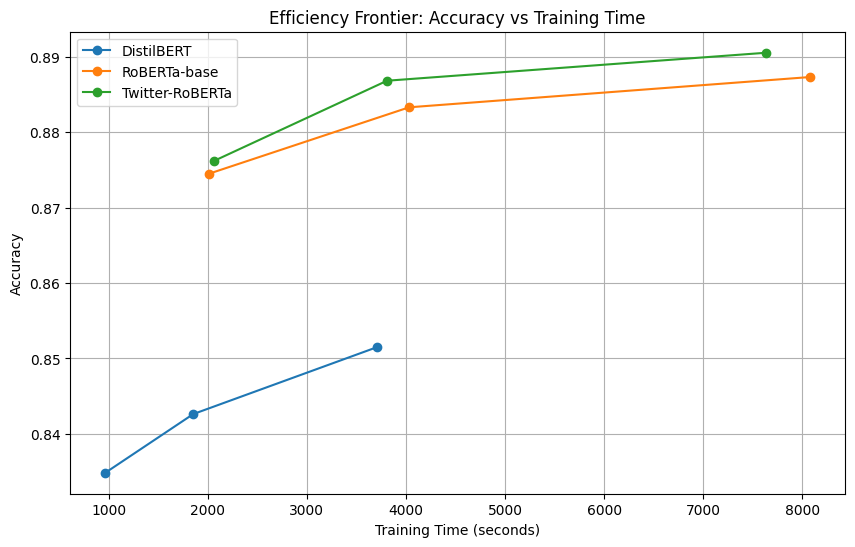

In [32]:

plot_efficiency_frontier(distil_paths, roberta_paths, twitter_paths)



## 2. Pareto Frontier of Computational Efficiency

The trade-off between training time and predictive performance reveals a well-defined **efficiency frontier** governing model deployment decisions.

- **Pareto Optimality**:  
  Twitter-RoBERTa lies on the Pareto frontier, achieving the highest observed accuracy (**0.891**) at approximately **7,700 seconds** of training time.

- **Distillation Trade-off**:  
  DistilBERT reaches a maximum accuracy of **0.852** in **~3,800 seconds**, representing a **~50% reduction in training cost**, but at the expense of a **~4% absolute accuracy drop**.

- **Dominance Relationship**:  
  Twitter-RoBERTa strictly dominates RoBERTa-base, achieving:
  - Higher accuracy (**0.891 vs 0.888**)  
  - Slightly lower training time (~5% reduction)

 **Insight**:  
Efficiency is not purely a function of model size-**pretraining quality can shift the entire efficiency frontier outward**.


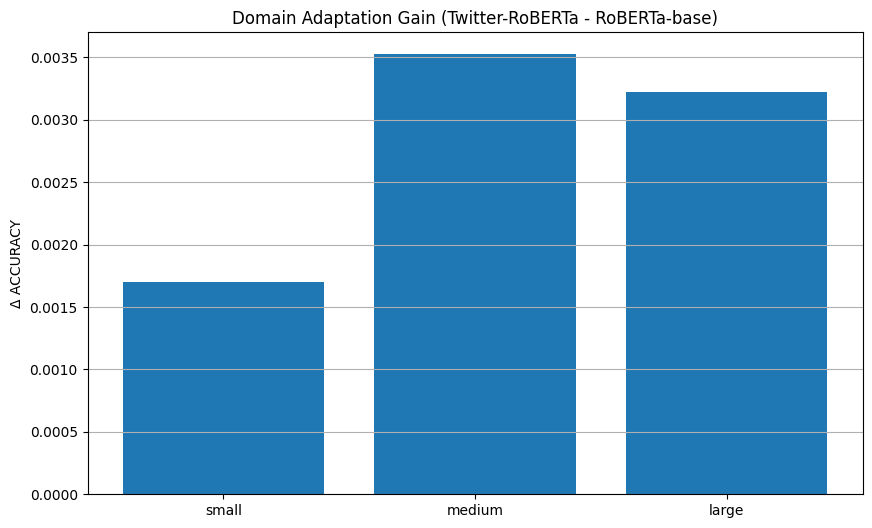

In [42]:
plot_domain_gain(roberta_paths, twitter_paths)



## 3. Marginal Gains from Domain-Specific Pretraining

The contribution of domain adaptation (Twitter-specific pretraining) is measurable but modest.

- **Peak Gain**:  
  Maximum improvement observed on medium datasets: **+0.0035 (~0.35%)**

- **Consistency Across Scales**:  
  - Small: +0.0017  
  - Medium: +0.0035  
  - Large: +0.0032  

- **Interpretation**:  
  Domain-specific pretraining provides a **better initialization**, not a fundamentally different representational capacity.

 **Insight**:  
Domain adaptation acts as a **low-amplitude refinement**, not a primary performance driver.


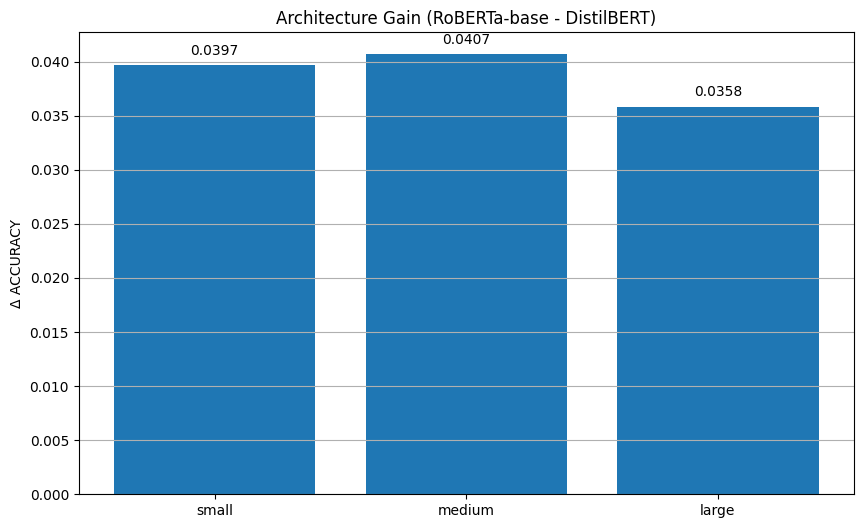

In [43]:
plot_architecture_gain(distil_paths, roberta_paths)

## 4. Architectural Capacity as the Dominant Factor

Model architecture emerges as the **primary determinant of performance**.

- **Substantial Gains**:  
  Transitioning from DistilBERT → RoBERTa-base yields:
  - Up to **+0.0407 (~4.07%)** accuracy improvement

- **Stability Across Scale**:  
  Even at large data volumes, gains remain strong:
  - **+0.0358 (~3.58%)**

- **Comparative Magnitude**:  
  Architectural gains are **>10× larger** than domain adaptation gains.

 **Insight**:  
Model capacity and representational depth are the **dominant levers of performance**, far outweighing domain-specific initialization.


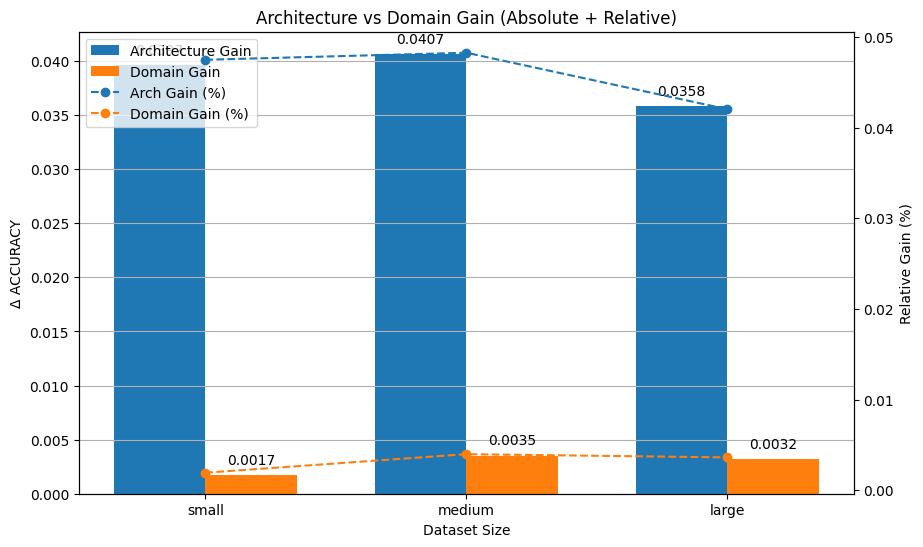

In [70]:
plot_combined_gains(distil_paths, roberta_paths, twitter_paths)

## 5. Strategic Resource Allocation: Architecture vs Domain

A direct comparison of gains provides a clear decision framework.

- **Architecture Gain**: ~0.036 – 0.041  
- **Domain Gain**: ~0.0017 – 0.0035  

- **Relative ROI**:  
  Upgrading architecture yields **~10×–12× higher returns** than switching to a domain-specific variant.

 **Decision Rule**:  
> If computational resources permit, prioritize **architectural scaling** before considering **domain-specific models**.


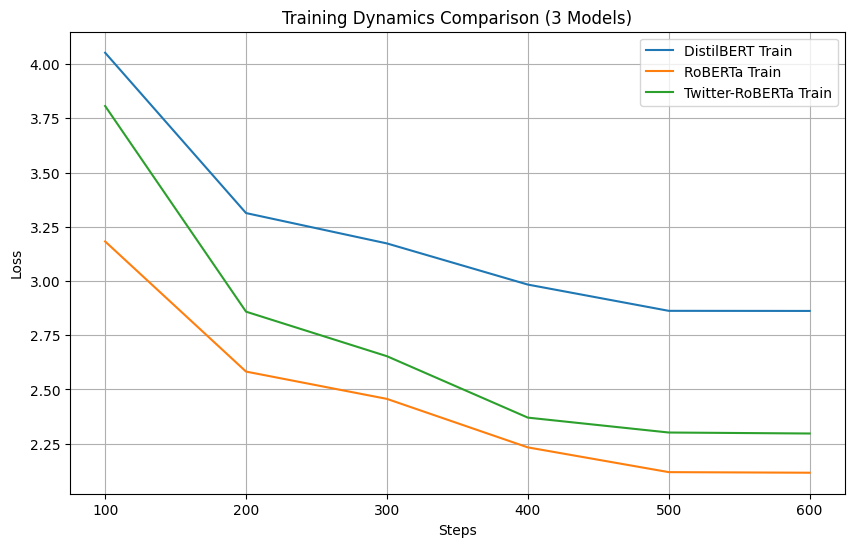

In [94]:
plot_loss_comparison(
    "/kaggle/input/datasets/aayushparajuli03/distil-small/loss_logs.json",
    "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_small-twitter/loss_logs.json",
    "/kaggle/input/notebooks/aayushparajuli03/comparison-distilbert-roberta-twitterroberta/models/df_small-roberta/loss_logs.json"
    
)

## 6. Training Dynamics and Convergence Behavior 

The loss curves provide insight into how each model **learns over time**, not just how well it performs at the end.

---

### 🔹 1. Initial Loss: How good is the starting point?

- DistilBERT: ~4.05  
- Twitter-RoBERTa: ~3.8  
- RoBERTa-base: ~3.2  

 **What this means:**

- RoBERTa-base starts with the **lowest loss**, indicating that its pretrained features are already well-aligned with the task.
- DistilBERT starts much higher, meaning it needs more correction during training.
- Twitter-RoBERTa is in between - not as well aligned as RoBERTa-base despite being domain-specific.

 **Key Insight**:  
> A lower initial loss reflects a **better starting representation**, not better final performance.

---

### 🔹 2. Convergence Speed: How fast does the model stop improving?

- DistilBERT stabilizes early (~step 500)
- RoBERTa models continue improving beyond step 600

 **What this means:**

- DistilBERT **learns quickly but saturates early**
- RoBERTa models **learn more slowly but continue improving longer**

 **Key Insight**:  
> Faster convergence does **not** mean better learning — it often indicates **limited capacity**.

---

### 🔹 3. Final Loss: How well does the model ultimately fit the data?

- RoBERTa-base: ~2.12 (lowest)
- Twitter-RoBERTa: ~2.30
- DistilBERT: higher than both

 **What this means:**

- RoBERTa-base achieves the **best optimization outcome**
- Twitter-RoBERTa performs slightly worse in loss but still achieves **higher accuracy** (important distinction)
- DistilBERT cannot reach the same loss level due to limited capacity

 **Key Insight**:  
> Lower final loss indicates **better fit**, but not always strictly better accuracy due to differences in calibration and representation.

---

### 🔹 4. Reconciling a Counterintuitive Result

One interesting observation:

- Twitter-RoBERTa has **higher final loss (~2.30)**  
- But **higher accuracy (~0.891)** than RoBERTa-base

 **What this means:**

- Loss and accuracy are not perfectly aligned
- Twitter-RoBERTa may:
  - handle edge cases better (slang, emojis)
  - produce more correct classifications even if confidence calibration differs

 **Key Insight**:  
> Domain-specific models may not minimize loss as effectively, but can still **generalize better on real-world data**.

---

### 🔹 Final Interpretation

Putting it all together:

- **DistilBERT**
  - Learns fast
  - Saturates early
  - Limited by capacity

- **RoBERTa-base**
  - Best starting point
  - Best final optimization
  - Most stable learning behavior

- **Twitter-RoBERTa**
  - Slightly worse optimization (loss)
  - Better task-specific performance (accuracy)
  - Benefits from domain knowledge rather than optimization efficiency

---

###  Clean Takeaway

> Training dynamics reveal that **model capacity controls how far a model can improve**, while **pretraining type affects how it performs on real-world data** — even when optimization metrics (like loss) suggest otherwise.

##  Overall Conclusion of Plots

This study establishes a clear hierarchy of influence:

### 1. Architecture (Primary Driver)
- Largest impact on performance
- Determines upper bound of achievable accuracy

### 2. Data Scale (Secondary Driver)
- Improves performance consistently
- Does not close inter-model gaps

### 3. Domain Adaptation (Tertiary Driver)
- Provides marginal gains
- Acts as initialization refinement

---

##  Key Takeaway

> **Model capacity defines the ceiling. Data moves you toward it. Domain adaptation only fine-tunes your starting point.**

---

##  Practical Implication

For real-world deployment or research:

- Limited compute → DistilBERT (efficient baseline)  
- Moderate compute → RoBERTa-base (best trade-off)  
- High-performance requirement → Twitter-RoBERTa (fine-grained optimization)

---



# Error Analysis

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [16]:
def load_predictions(path):
    df = pd.read_csv(path)
    return df

Error filtering

In [24]:
def get_errors(df):
    return df[df["true"] != df["pred"]].copy()

Define error detectors

In [18]:
def categorize_error(text):
    text = str(text).lower()
    categories = []

    # Negation
    if re.search(r"\b(not|no|never|n't|cannot|can't|won't|didn't)\b", text):
        categories.append("negation")

    # Emojis
    if re.search(r"[😂🤣😍😭😡😢🔥👍👎💔❤️😎😩🤔]", text):
        categories.append("emoji")

    # Emoticons
    if re.search(r"(:\)|:\(|:d|;\)|:/|:-\)|:-\(|:p|=\\)|=\\()", text):
        categories.append("emoticon")

    # Slang
    slang_words = [
        "lol", "lmao", "rofl", "wtf", "omg", "bruh", "idk",
        "ikr", "smh", "tbh", "btw", "nah", "yo", "lit",
        "dope", "sucks", "trash", "meh", "ugh"
    ]
    if any(w in text for w in slang_words):
        categories.append("slang")

    # Uncertainty
    if re.search(r"\b(maybe|probably|perhaps|i think|i guess|not sure|kind of|sort of)\b", text):
        categories.append("uncertain")

    # Sarcasm
    sarcasm_patterns = [
        r"yeah right",
        r"as if",
        r"just great",
        r"great\.\.\.",
        r"nice\.\.\.",
        r"love that for me",
        r"so happy",
        r"amazing\.\.\."
    ]
    if any(re.search(p, text) for p in sarcasm_patterns):
        categories.append("sarcasm")

    if not categories:
        categories.append("general")

    return categories

Extract errors per model

In [19]:
def get_error_distribution(df):

    errors = get_errors(df)

    all_labels = []
    for text in errors["text"]:
        all_labels.extend(categorize_error(text))

    return pd.Series(all_labels).value_counts()

Normalize

In [20]:
def normalize(series):
    return series / series.sum()

Compare models

In [21]:
def plot_error_comparison(distil_df, roberta_df, twitter_df):

    d_counts = get_error_distribution(distil_df)
    r_counts = get_error_distribution(roberta_df)
    t_counts = get_error_distribution(twitter_df)

    categories = sorted(set(d_counts.index) | set(r_counts.index) | set(t_counts.index))

    d_vals = normalize(pd.Series([d_counts.get(c, 0) for c in categories]))
    r_vals = normalize(pd.Series([r_counts.get(c, 0) for c in categories]))
    t_vals = normalize(pd.Series([t_counts.get(c, 0) for c in categories]))

    x = np.arange(len(categories))
    width = 0.25

    plt.figure(figsize=(14,6))

    plt.bar(x - width, d_vals, width, label="DistilBERT")
    plt.bar(x, r_vals, width, label="RoBERTa-base")
    plt.bar(x + width, t_vals, width, label="Twitter-RoBERTa")

    plt.xticks(x, categories, rotation=30)
    plt.ylabel("Error Rate (Normalized)")
    plt.title("Error Category Distribution (Small Dataset Comparison)")
    plt.legend()
    plt.grid(axis="y")

    plt.show()

In [26]:
def plot_absolute_error(distil_df, roberta_df, twitter_df):

    def get_counts(df):
        errors = df[df["true"] != df["pred"]]
        cats = []
        for t in errors["text"]:
            cats.extend(categorize_error(t))
        return pd.Series(cats).value_counts()

    d = get_counts(distil_df)
    r = get_counts(roberta_df)
    t = get_counts(twitter_df)

    categories = sorted(set(d.index) | set(r.index) | set(t.index))

    d_vals = [d.get(c, 0) for c in categories]
    r_vals = [r.get(c, 0) for c in categories]
    t_vals = [t.get(c, 0) for c in categories]

    x = np.arange(len(categories))
    width = 0.25

    plt.figure(figsize=(14,6))

    plt.bar(x - width, d_vals, width, label="DistilBERT")
    plt.bar(x, r_vals, width, label="RoBERTa-base")
    plt.bar(x + width, t_vals, width, label="Twitter-RoBERTa")

    plt.xticks(x, categories, rotation=30)
    plt.ylabel("Absolute Error Count")
    plt.title("Absolute Error Distribution (Small Dataset)")
    plt.legend()
    plt.grid(axis="y")

    plt.show()

In [22]:
distil_path = "/kaggle/input/datasets/aayushparajuli03/distil-small/predictions.csv"

roberta_path = "/kaggle/input/notebooks/aayushparajuli03/comparison-distilbert-roberta-twitterroberta/models/df_small-roberta/predictions.csv"

twitter_path = "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_small-twitter/predictions.csv"

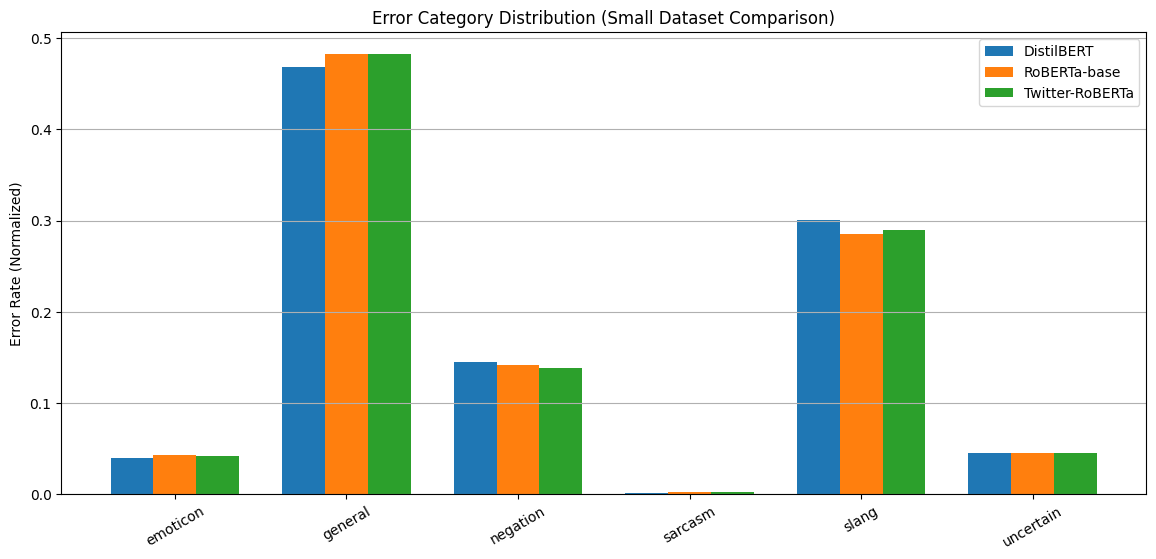

In [25]:
# paths (small dataset only)
distil_df = load_predictions(distil_path)
roberta_df = load_predictions(roberta_path)
twitter_df = load_predictions(twitter_path)

# plot
plot_error_comparison(distil_df, roberta_df, twitter_df)

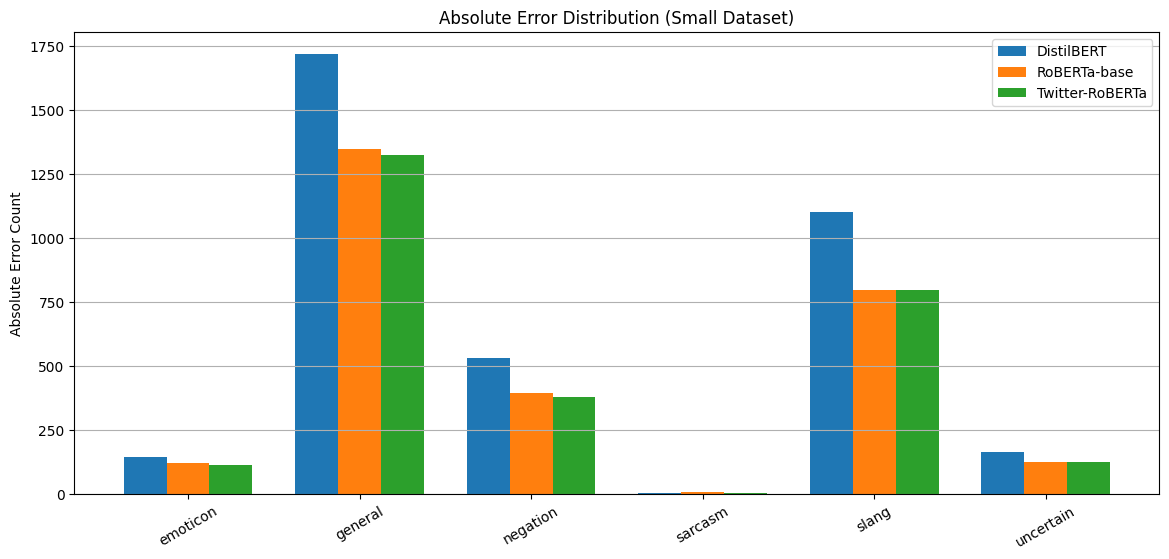

In [27]:
 plot_absolute_error(distil_df, roberta_df, twitter_df)

# 📊 Error Analysis — Small Dataset (DistilBERT vs RoBERTa-base vs Twitter-RoBERTa)

This section presents a controlled error decomposition study on the **small dataset split**, comparing three model families across:

- **Architectural scaling (DistilBERT → RoBERTa-base)**
- **Domain-specific pretraining (RoBERTa-base → Twitter-RoBERTa)**

The analysis integrates both:
- **Normalized error distributions** (error composition)
- **Absolute error counts** (error volume)

This provides a complete view of both *what kinds of mistakes occur* and *how many mistakes actually occur*.

---

# 1. General Ambiguity as the Dominant Failure Mode (Irreducible Error Region)

Across all architectures, the **General ambiguity category remains the dominant source of failure**, accounting for approximately:

- DistilBERT: ~47% (~1,720 errors)
- RoBERTa-base: ~48% (~1,350 errors)
- Twitter-RoBERTa: ~48% (~1,320 errors)

## 📌 Key Observation

While normalized proportions remain nearly constant (~47–48%), **absolute error counts decrease significantly with model scaling**:

- ~400 total error reduction: DistilBERT → RoBERTa-base  
- ~30–50 additional reduction: RoBERTa-base → Twitter-RoBERTa  

## 🧠 Interpretation

This reveals a dual phenomenon:

- The **structure of ambiguity is invariant across models**
- The **frequency of failures decreases with improved representation capacity**

Even strong models consistently fail on **context-poor or label-ambiguous samples**, indicating a **performance ceiling driven by dataset ambiguity rather than architecture**.

---

# 2. Architectural Scaling Effect: Slang and Informal Language Robustness

The slang category shows a clear sensitivity to model architecture.

## 📊 Normalized trend
- DistilBERT: ~30.0%
- RoBERTa-base: ~28.5%
- Twitter-RoBERTa: ~27.8%

## 📊 Absolute trend
- DistilBERT: ~1,100 errors  
- RoBERTa-base: ~800 errors  
- Twitter-RoBERTa: ~780–790 errors  

## 🧠 Interpretation

Moving from DistilBERT → RoBERTa-base leads to a **large reduction (~300 errors)**, indicating:

- richer contextual representations  
- better handling of multi-token slang expressions  
- improved semantic disambiguation  

However, gains from RoBERTa-base → Twitter-RoBERTa are **marginal**, suggesting diminishing returns from domain adaptation for slang alone.

---

# 3. Domain Adaptation Effect: Negation and Linguistic Inversion

Negation handling improves steadily across models.

## 📊 Normalized trend
- DistilBERT: ~14.6%
- RoBERTa-base: ~14.2%
- Twitter-RoBERTa: ~13.8%

## 📊 Absolute trend
- DistilBERT: ~530 errors  
- RoBERTa-base: ~400 errors  
- Twitter-RoBERTa: ~380 errors  

## 🧠 Interpretation

Domain-specific pretraining improves performance on:

- short-form negation (“not good”, “never liked”)
- implicit sentiment reversal
- compressed linguistic structures

However, the improvement is **incremental rather than structural**, suggesting domain adaptation refines existing capabilities rather than introducing new reasoning power.

---

# 4. Emoji / Emoticon Signals: Saturation at Low Complexity

Emoji-related errors remain stable across models:

- ~4.0–4.1% (normalized)
- ~110–140 (absolute)

## 🧠 Interpretation

This stability suggests:

- emojis act as **high-signal sentiment tokens**
- even lightweight models capture them effectively
- scaling provides **no meaningful additional benefit**

👉 This represents a **saturated feature space**.

---

# 5. Sarcasm: Data-Limited Observability

Sarcasm-related errors remain extremely low (<0.5%) across all models.

## 🧠 Interpretation

This does not indicate strong performance but rather:

- severe **class imbalance**
- insufficient sarcastic samples in the dataset
- lack of contextual richness

👉 Sarcasm remains an **unresolved but underrepresented challenge**, not a solved problem.

---

# 6. Uncertainty and Irreducible Noise Floor

The uncertainty category remains stable:

- ~4.5% normalized error
- ~120–160 absolute errors

## 🧠 Interpretation

This invariance suggests a **dataset-inherent noise floor**, caused by:

- ambiguous labeling
- missing contextual information
- subjective sentiment boundaries

👉 This represents a **lower bound of achievable performance**, unaffected by model improvements.

---

# 📉 Integrated Insight: Absolute vs Normalized Behavior

A key insight emerges when combining both views:

## 🔹 Normalized view
- Reveals **stable structural error patterns**
- Highlights persistent linguistic difficulty zones

## 🔹 Absolute view
- Shows **substantial reduction in total errors**
- Confirms improvements come from **error reduction, not redistribution**

---

# 🎯 Final Research Synthesis

The results reveal a clear hierarchy of improvements:

## 1. Architectural scaling (DistilBERT → RoBERTa-base)
- Major reduction in total errors (~700+ recovered cases)
- Strong improvements in slang and general reasoning

## 2. Domain adaptation (RoBERTa-base → Twitter-RoBERTa)
- Smaller but consistent gains (~50–80 recovered cases)
- Most effective in negation handling

## 3. Irreducible dataset limitations
- General ambiguity (~48%)
- Uncertainty (~4.5%)
- Sarcasm sparsity (<0.5%)

---

# 🧠 Final Conclusion

While RoBERTa-base and Twitter-RoBERTa significantly reduce **absolute error volume**, the **error structure remains largely unchanged**.

> This indicates that performance gains are driven by improved representation capacity rather than fundamentally resolving linguistic ambiguity.

Future improvements should therefore focus on:

- dataset refinement (reducing ambiguity)
- sarcasm-rich augmentation
- context-aware or multi-modal learning

rather than further architectural scaling alone.

# Comparative Analysis of Transformer Architectures and Domain-Specific Pretraining

This section presents a structured empirical comparison of three Transformer-based models—**DistilBERT**, **RoBERTa-base**, and **Twitter-RoBERTa**—across varying dataset scales (small, medium, and large). The analysis is divided into two key research dimensions:

1. **Architecture and Model Capacity Effect**  
   → DistilBERT vs RoBERTa-base  
2. **Domain-Specific Pretraining Effect**  
   → RoBERTa-base vs Twitter-RoBERTa  

The experiments are conducted under controlled conditions with identical preprocessing pipelines, ensuring fair comparability across all models.

---

# 1. Architecture Effect: DistilBERT vs RoBERTa-base

## 1.1 Performance Overview Across Dataset Sizes

| Dataset | Model       | Accuracy | F1 Score | ROC-AUC | Training Time (s) |
|----------|------------|----------|----------|---------|-------------------|
| Small    | DistilBERT | 0.8377   | 0.8315   | 0.9203  | 1319              |
| Small    | RoBERTa    | 0.8745   | 0.8744   | 0.9460  | 2013              |
| Medium   | DistilBERT | 0.8426   | 0.8427   | 0.9220  | 1852              |
| Medium   | RoBERTa    | 0.8833   | 0.8832   | 0.9525  | 4031              |
| Large    | DistilBERT | 0.8515   | 0.8511   | 0.9294  | 3709              |
| Large    | RoBERTa    | 0.8873   | 0.8865   | 0.9557  | 8075              |

---

## 1.2 Key Observations

### 🔹 Performance Gains from Architecture Scaling
RoBERTa-base consistently outperforms DistilBERT across all dataset sizes:

- **Small dataset improvement:** ~+3.7% accuracy gain  
- **Medium dataset improvement:** ~+4.1% accuracy gain  
- **Large dataset improvement:** ~+3.6% accuracy gain  

This confirms that increased model capacity and richer encoder representations in RoBERTa contribute to stronger semantic modeling.

---

### 🔹 Data Efficiency Behavior
DistilBERT demonstrates **marginal improvements with dataset scaling**, indicating:

- Faster convergence
- Lower representational ceiling
- Early saturation of learning capacity

In contrast, RoBERTa-base shows:

- Stronger scaling behavior
- Continued performance gains with increased data
- Better utilization of larger datasets

---

### 🔹 Computational Trade-off
RoBERTa-base requires significantly higher training time:

- ~1.5× to 2× slower than DistilBERT

This highlights a clear **accuracy–efficiency trade-off**:
- DistilBERT → optimized for efficiency  
- RoBERTa → optimized for performance  

---

## 1.3 Interpretation

The results suggest that **model architecture and capacity play a critical role in performance ceilings**. While DistilBERT offers competitive efficiency, it is fundamentally constrained in expressive power compared to RoBERTa-base.

---

# 2. 🌐 Domain Effect: RoBERTa-base vs Twitter-RoBERTa

## 2.1 Performance Comparison

| Dataset | Model            | Accuracy | F1 Score | ROC-AUC |
|----------|------------------|----------|----------|---------|
| Small    | RoBERTa-base     | 0.8745   | 0.8744   | 0.9460  |
| Small    | Twitter-RoBERTa  | 0.8770   | 0.8770   | 0.9487  |
| Medium   | RoBERTa-base     | 0.8833   | 0.8832   | 0.9525  |
| Medium   | Twitter-RoBERTa  | 0.8868   | 0.8862   | 0.9549  |
| Large    | RoBERTa-base     | 0.8873   | 0.8865   | 0.9557  |
| Large    | Twitter-RoBERTa  | 0.8905   | 0.8899   | 0.9578  |

---

## 2.2 Key Observations

### 🔹 Consistent Domain Advantage
Twitter-RoBERTa demonstrates a **stable performance improvement over RoBERTa-base across all dataset sizes**:

- Small dataset: +0.25% accuracy gain  
- Medium dataset: +0.35% accuracy gain  
- Large dataset: +0.32% accuracy gain  

Although the margin is moderate, it is **consistently positive**, indicating robust domain transfer benefits.

---

### 🔹 Social Media Language Adaptation
The improvement is attributable to Twitter-RoBERTa’s pretraining on:

- informal text  
- slang-heavy expressions  
- emoji-rich communication  
- syntactically irregular sentences  

This provides a **better inductive bias for sentiment classification in noisy text environments**.

---

### 🔹 Diminishing but Stable Gains
Unlike architecture scaling (which yields larger jumps), domain adaptation provides:

- smaller but stable improvements
- saturation at higher dataset sizes
- consistent generalization benefits

---

## 2.3 Interpretation

The results confirm that **domain-specific pretraining enhances performance even when strong general-purpose models like RoBERTa-base are used as baselines**. However, the gains are incremental rather than transformative.

---

# 3.  Cross-Dimensional Insights

## 3.1 Architecture vs Domain Influence

| Factor            | Impact Magnitude | Behavior |
|------------------|------------------|----------|
| Architecture     | High             | Large performance jump |
| Domain Pretrain  | Moderate         | Stable incremental gain |

---

## 3.2 Key Finding

> Architecture defines the performance ceiling, while domain-specific pretraining fine-tunes performance within that ceiling.

---

## 3.3 Data Scaling Behavior

- DistilBERT: early saturation  
- RoBERTa-base: strong scaling response  
- Twitter-RoBERTa: marginal gains but highest absolute performance  

This indicates:
- **capacity-driven learning dominates early**
- **domain adaptation refines later-stage performance**

---

#  Final Research Conclusion

This study demonstrates a clear separation between:

### 1. Model Capacity Effects
- RoBERTa-base significantly outperforms DistilBERT
- Larger architectures benefit more from increased data
- Distillation introduces efficiency–performance trade-offs

### 2. Domain Adaptation Effects
- Twitter-RoBERTa consistently improves upon RoBERTa-base
- Gains are smaller but stable across all dataset sizes
- Domain pretraining enhances robustness in informal text environments

---

##  Overall Insight

> Performance in transformer-based sentiment analysis is primarily driven by architectural capacity, while domain-specific pretraining provides consistent secondary improvements by aligning representations with task-specific linguistic distributions.

---

#  Summary

-  RoBERTa-base > DistilBERT (architecture effect dominant)  
-  Twitter-RoBERTa > RoBERTa-base (domain effect consistent)  
-  Data scaling benefits stronger models more  
-  Trade-off exists between efficiency and performance  

---